In [1]:
import pandas as pd

from se_analysis import project, read_files

pd.set_option('display.max_colwidth', None)   # no truncation at all

In [2]:
data_dir = project("Sundance CO")
str(data_dir)

'C:\\Users\\bftro\\code\\py\\se-analysis\\projects\\Sundance CO'

In [3]:
reader = read_files(data_dir, file_type="log")

2026-08-24 04:59:31,870 | INFO | [logr:559] | Concatenating 2 files...


Time elapsed: 0 s | 2  / 2  [=============================================] 100%	

2026-08-24 04:59:31,881 | INFO | [logr:677] | Concatenation of 284 rows complete


In [4]:
reader.Site_info

,0,1
0,Model Number:,9458
1,Serial Number:,945800233
2,Created FW Version:,001.03.018
3,Bootloader Version:,001.00.002
4,Site Properties,NaN
5,Site:,233
6,Project:,"Sundance,CO"
7,Location:,INV 16
8,Coordinate System:,WGS84
9,Latitude:,39.40488


In [5]:
df = reader.data

In [6]:
df[
    df["EventType"] == "FAULT"
]

,Timestamp,EpochTime,EventType,Description,Details
2,2026-08-16T00:08:45Z,1786838925,FAULT,SRVEL_ERR_SERIAL_BOARD,Fault Detected: SERIAL_FAULT_COMA
3,2026-08-16T00:08:54Z,1786838934,FAULT,SRVEL_ERR_SERIAL_BOARD,Fault Cleared: SERIAL_FAULT_COMA
9,2026-08-16T01:20:42Z,1786843242,FAULT,SRVEL_ERR_SERIAL_BOARD,Fault Detected: SERIAL_FAULT_COMB
10,2026-08-16T01:20:51Z,1786843251,FAULT,SRVEL_ERR_SERIAL_BOARD,Fault Cleared: SERIAL_FAULT_COMB
48,2026-08-16T08:03:38Z,1786867418,FAULT,SRVEL_ERR_SPI_CRC_FAIL,"Serial Card SPI Command frame CRC Validation failed [CRC: 1526413624; ID: 2, Cmd: 5]"
65,2026-08-16T11:08:44Z,1786878524,FAULT,SRVEL_ERR_SERIAL_BOARD,Fault Detected: SERIAL_FAULT_COMA
66,2026-08-16T11:08:53Z,1786878533,FAULT,SRVEL_ERR_SERIAL_BOARD,Fault Cleared: SERIAL_FAULT_COMA
68,2026-08-16T11:33:25Z,1786880005,FAULT,SRVEL_ERR_SPI_CRC_FAIL,"Serial Card SPI Command frame CRC Validation failed [CRC: 1423803284; ID: 2, Cmd: 5]"
71,2026-08-16T11:40:13Z,1786880413,FAULT,SRVEL_ERR_SPI_CRC_FAIL,"Serial Card SPI Command frame CRC Validation failed [CRC: 1343753529; ID: 2, Cmd: 5]"
76,2026-08-16T12:00:26Z,1786881626,FAULT,SRVEL_ERR_SPI_CRC_FAIL,"Serial Card SPI Command frame CRC Validation failed [CRC: -2026592664; ID: 2, Cmd: 5]"


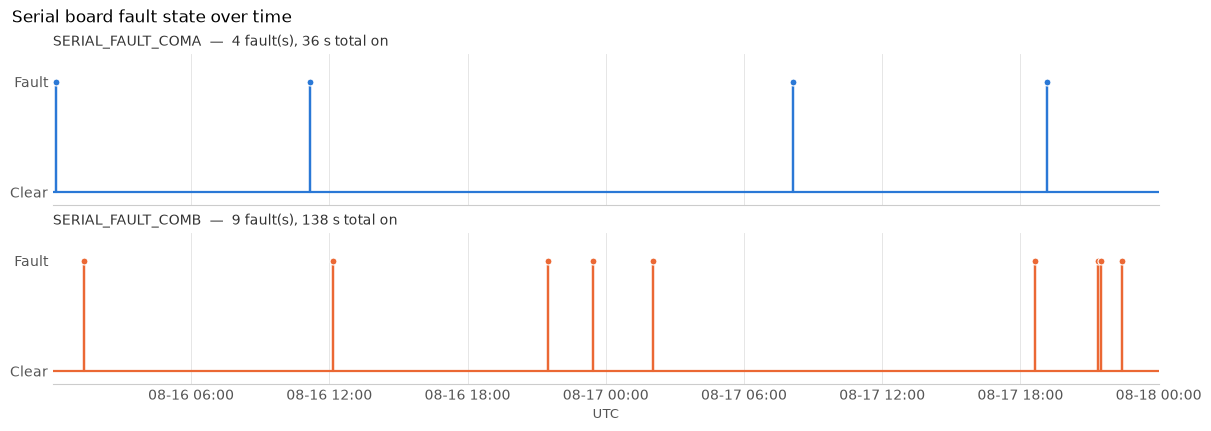

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CHANNELS = {
    "SERIAL_FAULT_COMA": "#2a78d6",
    "SERIAL_FAULT_COMB": "#eb6834",
}

t = pd.to_datetime(df["Timestamp"], utc=True)
t0, t1 = t.min(), t.max()

ev = df.loc[df["EventType"] == "FAULT", ["Timestamp", "Details"]].copy()
ev["t"] = pd.to_datetime(ev["Timestamp"], utc=True)
ev = ev.sort_values("t")


def transitions(channel):
    """Detected/Cleared events -> (times, states), padded to the log's time span."""
    e = ev[ev["Details"].str.contains(channel, regex=False)]
    times, states = [t0], [0]
    for ts, detail in zip(e["t"], e["Details"]):
        times.append(ts)
        states.append(1 if detail.startswith("Fault Detected") else 0)
    times.append(t1)          # hold the last known state to the end of the log
    states.append(states[-1])
    return times, states


def intervals(times, states):
    """Contiguous ON spans as (on, off, seconds)."""
    out, start = [], None
    for ts, s in zip(times, states):
        if s == 1 and start is None:
            start = ts
        elif s == 0 and start is not None:
            out.append((start, ts, (ts - start).total_seconds()))
            start = None
    if start is not None:      # still faulted when the log ends
        out.append((start, t1, (t1 - start).total_seconds()))
    return out


fig, axes = plt.subplots(
    len(CHANNELS), 1, figsize=(12, 4.2), sharex=True, constrained_layout=True
)

for ax, (channel, color) in zip(axes, CHANNELS.items()):
    times, states = transitions(channel)
    spans = intervals(times, states)

    ax.step(times, states, where="post", color=color, lw=1.6)
    # faults last seconds inside a multi-day window, so mark each onset
    ax.plot(
        [on for on, _, _ in spans], [1] * len(spans),
        "o", ms=5, color=color, mec="white", mew=0.8, zorder=3,
    )

    ax.set_ylim(-0.12, 1.25)
    ax.set_yticks([0, 1], ["Clear", "Fault"])
    ax.set_title(
        f"{channel}  —  {len(spans)} fault(s), "
        f"{sum(d for _, _, d in spans):.0f} s total on",
        loc="left", fontsize=10, color="#333333",
    )
    ax.grid(axis="x", color="#e6e6e6", lw=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#555555", length=0)

axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
axes[-1].set_xlim(t0, t1)
axes[-1].set_xlabel("UTC", color="#555555", fontsize=9)
fig.suptitle("Serial board fault state over time", x=0.005, ha="left", fontsize=12)
plt.show()

In [8]:
faults = pd.DataFrame(
    [
        {"Fault": channel, "On": on, "Off": off, "Seconds": secs}
        for channel in CHANNELS
        for on, off, secs in intervals(*transitions(channel))
    ]
).sort_values("On").reset_index(drop=True)

faults

,Fault,On,Off,Seconds
0,SERIAL_FAULT_COMA,2026-08-16 00:08:45+00:00,2026-08-16 00:08:54+00:00,9.0
1,SERIAL_FAULT_COMB,2026-08-16 01:20:42+00:00,2026-08-16 01:20:51+00:00,9.0
2,SERIAL_FAULT_COMA,2026-08-16 11:08:44+00:00,2026-08-16 11:08:53+00:00,9.0
3,SERIAL_FAULT_COMB,2026-08-16 12:08:35+00:00,2026-08-16 12:08:44+00:00,9.0
4,SERIAL_FAULT_COMB,2026-08-16 21:29:41+00:00,2026-08-16 21:30:20+00:00,39.0
5,SERIAL_FAULT_COMB,2026-08-16 23:26:17+00:00,2026-08-16 23:26:26+00:00,9.0
6,SERIAL_FAULT_COMB,2026-08-17 02:02:49+00:00,2026-08-17 02:02:58+00:00,9.0
7,SERIAL_FAULT_COMA,2026-08-17 08:08:42+00:00,2026-08-17 08:08:51+00:00,9.0
8,SERIAL_FAULT_COMB,2026-08-17 18:37:40+00:00,2026-08-17 18:37:49+00:00,9.0
9,SERIAL_FAULT_COMA,2026-08-17 19:08:41+00:00,2026-08-17 19:08:50+00:00,9.0
